<a href="https://colab.research.google.com/github/190yenz406/UTS-ANREG-SANAH-24/blob/main/UTSANREG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress, shapiro
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


df = pd.read_csv('/content/bodyfat.csv')
BodyFat = "BodyFat"
Weight = "Weight"
display(df[[BodyFat, Weight]].head())


,BodyFat,Weight
0,12.3,154.25
1,6.1,173.25
2,25.3,154.00
3,10.4,184.75
4,28.7,184.25


PEMBERSIHAN DATA


In [53]:
print('====pemberssihan data=====')
#missing value
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")


#Hapus duplikasi
df = df.drop_duplicates()

#Deteksi Outlier
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nUkuran data setelah cleaning:", df.shape)

# Reset index
df = df.reset_index(drop=True)

print("\nData berhasil dibersihkan.")

====pemberssihan data=====
Total missing values: 0

Ukuran data setelah cleaning: (230, 15)

Data berhasil dibersihkan.


STATISTIKA DESKRIFTIF

In [54]:
#statistika deskriftif
print("\nStatistik Deskriptif:")
print(df[['BodyFat', 'Weight']].describe())

BodyFat_cleaned_array = df[BodyFat].values
Weight_cleaned_array = df[Weight].values



Statistik Deskriptif:
          BodyFat      Weight
count  230.000000  230.000000
mean    18.523478  176.119783
std      7.873407   24.122487
min      0.000000  118.500000
25%     12.325000  158.062500
50%     18.750000  174.875000
75%     24.575000  193.062500
max     40.100000  241.250000


MODEL REGRESI LINEAR BERGANDA

In [55]:

X_ols = sm.add_constant(df[BodyFat]) # Menambahkan konstanta ke variabel independen
y_ols = df[Weight] # Variabel dependen

# Membuat model OLS (Ordinary Least Squares)
model = sm.OLS(y_ols, X_ols).fit()

print("Ringkasan model:")
print(model.summary())

Ringkasan model:
                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     111.6
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.71e-21
Time:                        16:22:48   Log-Likelihood:                -1012.2
No. Observations:                 230   AIC:                             2028.
Df Residuals:                     228   BIC:                             2035.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.5846      3.345   

### Uji Asumsi Klasik

#### 1. Uji Normalitas (Residuals)
Uji normalitas bertujuan untuk mengetahui apakah nilai residual terdistribusi normal atau tidak. Metode yang digunakan adalah Shapiro-Wilk Test dan visualisasi Q-Q Plot serta Histogram.


--- Uji Normalitas (Shapiro-Wilk Test) ---
Statistik Uji: 0.982, P-value: 0.005
Keputusan: Tolak H0. Residual tidak terdistribusi normal.


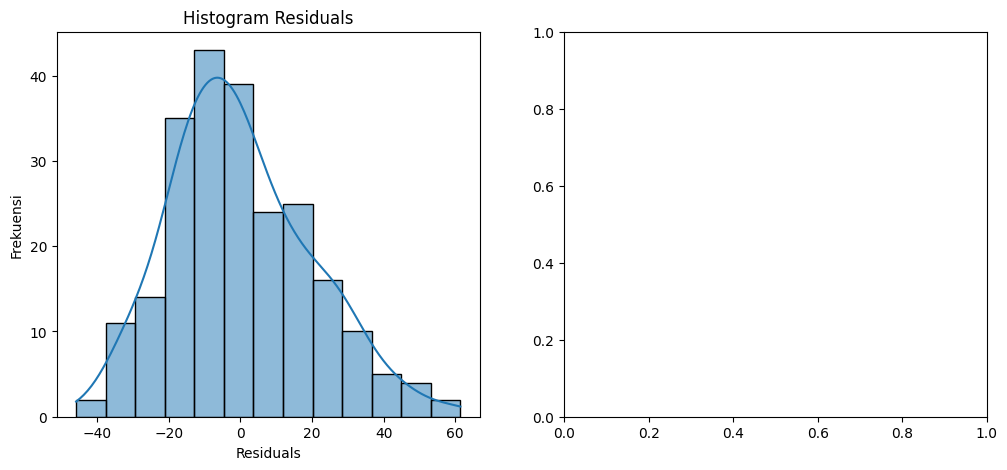

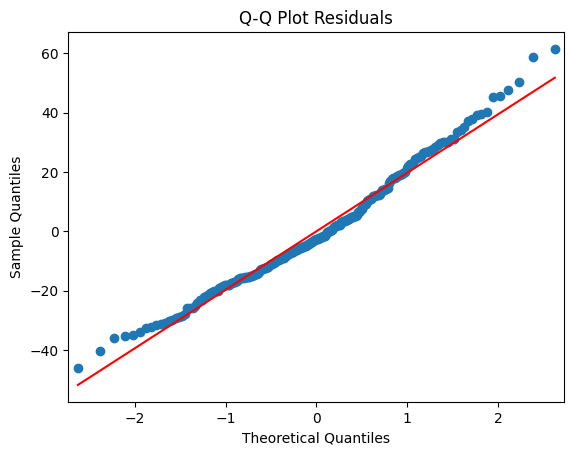

In [56]:
from scipy.stats import shapiro
import seaborn as sns

# Calculate residuals
residuals = model.resid

print("\n--- Uji Normalitas (Shapiro-Wilk Test) ---")
stat, p = shapiro(residuals)
print(f'Statistik Uji: {stat:.3f}, P-value: {p:.3f}')

if p > 0.05:
    print('Keputusan: Gagal menolak H0. Residual terdistribusi normal.')
else:
    print('Keputusan: Tolak H0. Residual tidak terdistribusi normal.')

# Visualisasi Histogram Residuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frekuensi')

# Visualisasi Q-Q Plot Residuals
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot Residuals')
plt.show()

#### 2. Uji Heteroskedastisitas
Uji heteroskedastisitas bertujuan untuk mengetahui apakah terdapat ketidaksamaan varians dari residual pada semua pengamatan. Jika varians residual konstan, maka disebut homoskedastisitas. Jika tidak, disebut heteroskedastisitas. Metode yang digunakan adalah visualisasi Scatter Plot Residuals vs Fitted Values dan Breusch-Pagan Test.


--- Uji Heteroskedastisitas (Breusch-Pagan Test) ---
{'LM Statistic': np.float64(0.14589715717696183), 'LM Test P-value': np.float64(0.7024874268171404), 'F-Statistic': np.float64(0.1447202874559683), 'F-Test P-value': np.float64(0.7039869544920425)}
Keputusan: Gagal menolak H0. Tidak ada heteroskedastisitas (homoskedastisitas).


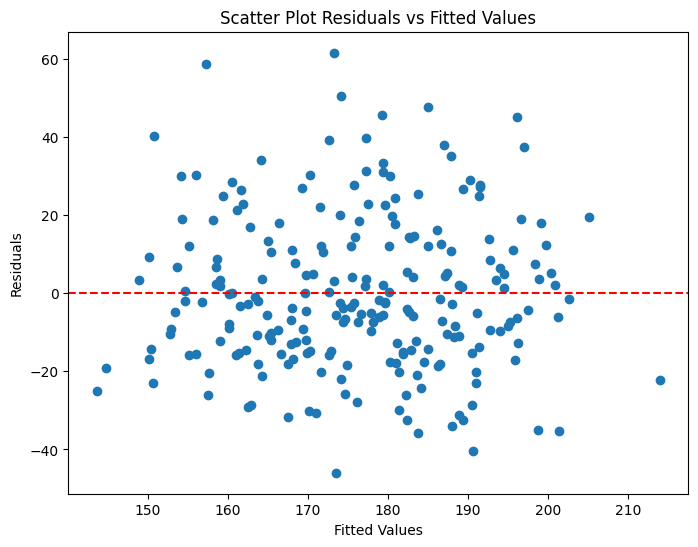

In [57]:

# Fitted values
fitted_values = model.fittedvalues

print("\n--- Uji Heteroskedastisitas (Breusch-Pagan Test) ---")
bp_test = het_breuschpagan(residuals, model.model.exog)
labels = ['LM Statistic', 'LM Test P-value', 'F-Statistic', 'F-Test P-value']
print(dict(zip(labels, bp_test)))

if bp_test[1] > 0.05:
    print('Keputusan: Gagal menolak H0. Tidak ada heteroskedastisitas (homoskedastisitas).')
else:
    print('Keputusan: Tolak H0. Terdapat heteroskedastisitas.')

# Visualisasi Scatter Plot Residuals vs Fitted Values
plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Scatter Plot Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

#### 3. Uji Autokorelasi
Uji autokorelasi bertujuan untuk mengetahui apakah ada korelasi antara residual pada periode t dengan residual pada periode sebelumnya (t-1). Metode yang digunakan adalah Durbin-Watson Test.

In [58]:

print("\n--- Uji Autokorelasi (Durbin-Watson Test) ---")
dw_statistic = durbin_watson(residuals)
print(f'Statistik Durbin-Watson: {dw_statistic:.3f}')

print("Hipotesis Nol (H0): Tidak ada autokorelasi.")

if 1.5 < dw_statistic < 2.5:
    print('Keputusan: Gagal tolak H0. Tidak ada autokorelasi.')
elif dw_statistic <= 1.5:
    print('Keputusan: Tolak H0. Terdapat autokorelasi positif.')
else:
    print('Keputusan: Tolak H0. Terdapat autokorelasi negatif.')


--- Uji Autokorelasi (Durbin-Watson Test) ---
Statistik Durbin-Watson: 1.705
Hipotesis Nol (H0): Tidak ada autokorelasi.
Keputusan: Gagal tolak H0. Tidak ada autokorelasi.


INTERPRETASI MODEL REGRESI LINEAR BERGANDA

Interpretasi: Korelasi sedang positif


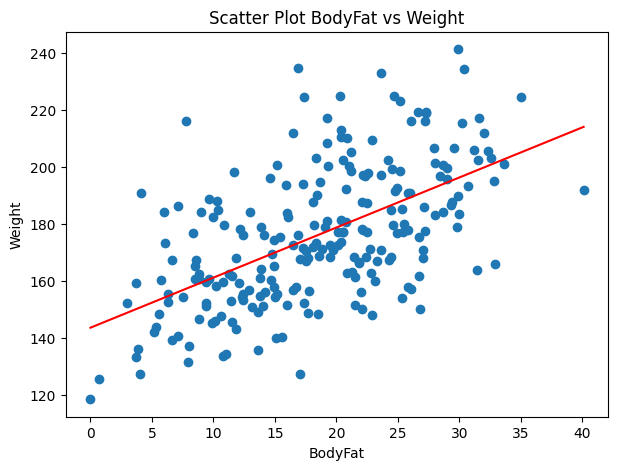

In [59]:
korelasi_pearson, p_value = pearsonr(BodyFat_cleaned_array, Weight_cleaned_array)
# Interpretasi hasil
if korelasi_pearson > 0.8:
  interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
  interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
  interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
  interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
  interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
  interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
  interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
  interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
  interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
  interpretasi = "Korelasi sangat lemah negatif"
else: interpretasi = "Tidak ada korelasi linier (atau sangat mendekati nol)"

print(f"Interpretasi: {interpretasi}")



#SCATTERPLOT DENGAN GARIS REGRESI
X_ols = sm.add_constant(df[BodyFat])
y_ols = df[Weight]
model = sm.OLS(y_ols, X_ols).fit()

plt.figure(figsize=(7,5))
plt.scatter(df[BodyFat], df[Weight])

slope_linregress, intercept_linregress, _, _, _ = linregress(df[BodyFat], df[Weight])
X_line = np.linspace(df[BodyFat].min(), df[BodyFat].max(), 100)
Y_line = intercept_linregress + slope_linregress * X_line
plt.plot(X_line, Y_line, color='red')

plt.xlabel(BodyFat)
plt.ylabel(Weight)
plt.title(f"Scatter Plot {BodyFat} vs {Weight}")
plt.show()

In [60]:
#INTERPRETASI KOEFISIEN
print("\nINTERPRETASI KOEFISIEN ")
intercept = model.params['const']
slope = model.params[BodyFat]
print(f"Persamaan Regresi: {Weight} = {round(intercept,2)} + {round(slope,2)} * {BodyFat}\n")

print("Interpretasi:")
print(f"1. Intercept (β0 = {round(intercept,2)}):")
print(f"   Nilai {Weight} ketika {BodyFat} = 0 adalah {round(intercept,2)} poin \n")

print(f"2. Slope (β1 = {round(slope,2)}):")
print(f"   Setiap penambahan 1 unit {BodyFat}, nilai {Weight} berubah sebesar {round(slope,2)} poin")



INTERPRETASI KOEFISIEN 
Persamaan Regresi: Weight = 143.58 + 1.76 * BodyFat

Interpretasi:
1. Intercept (β0 = 143.58):
   Nilai Weight ketika BodyFat = 0 adalah 143.58 poin 

2. Slope (β1 = 1.76):
   Setiap penambahan 1 unit BodyFat, nilai Weight berubah sebesar 1.76 poin


In [61]:
# Hitung koefisien korelasi Pearson dan p-value
# Tetapkan tingkat signifikansi (alpha)
alpha = 0.05
print(f"\nKoefisien Korelasi Pearson antara Variabel X ({BodyFat}) dan Variabel Y ({Weight}): {korelasi_pearson:.3f}")
print(f"P-value antara Variabel X ({BodyFat}) dan Variabel Y ({Weight}): {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

#Lakukan uji hipotesis
if p_value < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = f"Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara {BodyFat} dan {Weight} dalam populasi."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = f"Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara {BodyFat} dan {Weight} dalam populasi."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")


Koefisien Korelasi Pearson antara Variabel X (BodyFat) dan Variabel Y (Weight): 0.573
P-value antara Variabel X (BodyFat) dan Variabel Y (Weight): 0.000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara BodyFat dan Weight dalam populasi.


MEPREDIKSI BANYAKNYA OBESITAS

Jumlah orang obesitas: 53
MAE: 15.71711267455423
R2: 0.3286572046683458
   BodyFat  Weight_Asli  Weight_Prediksi
0     12.3       154.25       165.188676
1      6.1       173.25       154.298808
2     25.3       154.00       188.022271
3     10.4       184.75       161.851458
4     28.7       184.25       193.994135


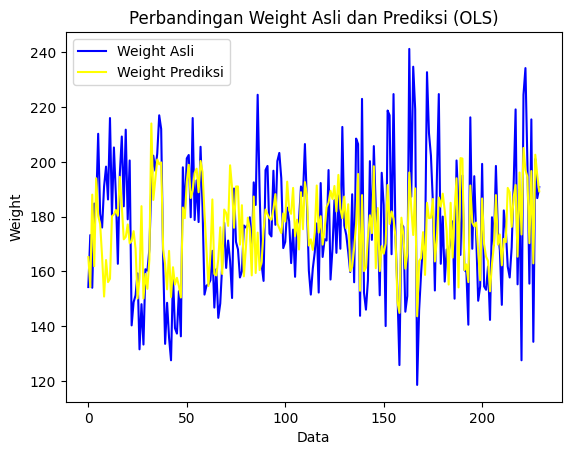

In [62]:
X_ols = sm.add_constant(df[BodyFat])
y_ols = df[Weight]
model = sm.OLS(y_ols, X_ols).fit()
# Prediksi weight
y_pred = model.predict(X_ols)

# Evaluasi
mae = mean_absolute_error(y_ols, y_pred)
r2 = r2_score(y_ols, y_pred)

hasil_prediksi = pd.DataFrame({
    "BodyFat": df[BodyFat],
    "Weight_Asli": y_ols,
    "Weight_Prediksi": y_pred
})


# Menentukan obesitas
df['Obesity'] = df['BodyFat'].apply(lambda x: 1 if x > 25 else 0)
print("Jumlah orang obesitas:", df['Obesity'].sum())
print("MAE:", mae)
print("R2:", r2)
print(hasil_prediksi.head())


# Grafik perbandingan
plt.figure()

plt.plot(y_ols.values, label="Weight Asli", color="blue")
plt.plot(y_pred.values, label="Weight Prediksi", color="yellow")

plt.title("Perbandingan Weight Asli dan Prediksi (OLS)")
plt.xlabel("Data")
plt.ylabel("Weight")
plt.legend()

plt.show()
